# 🎭 버추얼 아이돌 TF-IDF & N-gram 연관도 분석

YouTube 댓글 토큰화 데이터를 기반으로 TF-IDF 가중치와 N-gram 분석을 통해 버추얼 아이돌에 대한 여론을 심층 분석합니다.

## 📋 분석 내용
1. **TF-IDF 분석**: 문서 내 단어의 중요도 측정
2. **N-gram 분석**: Unigram, Bigram, Trigram 패턴 분석
3. **동시출현 분석**: 단어 간 Co-occurrence 분석
4. **PMI 연관도**: 단어 쌍 간 연관 강도 측정
5. **네트워크 시각화**: 단어 관계 그래프

---
## 1. 라이브러리 임포트 및 설정

In [ ]:
# 필요한 라이브러리 설치 (필요시 주석 해제)
# !pip install scikit-learn pandas numpy matplotlib seaborn networkx wordcloud

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import ast
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 네트워크 시각화
import networkx as nx

# 한글 폰트 설정
try:
    import koreanize_matplotlib
    print("✅ koreanize_matplotlib 로드 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
    # plt.rcParams['font.family'] = 'AppleGothic'  # Mac
    # plt.rcParams['font.family'] = 'NanumGothic'  # Linux
    print("✅ 한글 폰트 설정 완료 (Malgun Gothic)")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)

# 다크 스타일 설정
plt.style.use('dark_background')

print("✅ 모든 라이브러리 로드 완료!")

✅ koreanize_matplotlib 로드 완료
✅ 모든 라이브러리 로드 완료!


---
## 2. 데이터 로드 및 전처리

In [24]:
# CSV 파일 로드
df = pd.read_csv('./data/Youtube_comment_01/raw/subsets/youtube_comments_N_A.csv')

print(f"📊 원본 데이터 정보")
print(f"   - 총 행 수: {len(df)}")
print(f"   - 컬럼: {df.columns.tolist()}")
print(f"   - 결측치: {df['keywords'].isnull().sum()}개")

df.head(10)

📊 원본 데이터 정보
   - 총 행 수: 4656
   - 컬럼: ['Unnamed: 0', 'keywords']
   - 결측치: 430개


,Unnamed: 0,keywords
0,qOB5sIujPH8,NaN
1,qOB5sIujPH8,"['트윗', '사람', '아니다', '조롱']"
2,qOB5sIujPH8,"['솔직하다', '응원']"
3,qOB5sIujPH8,"['서현', '팬덤', '케이팝', '팬덤', '공공', '업보', '없다']"
4,qOB5sIujPH8,"['아니다', '버츄얼', '아이돌', '플레이', '듣보잡', '스텔라', '이브..."
5,qOB5sIujPH8,['알고리즘']
6,qOB5sIujPH8,"['자기', '재밌다', '같다', '진짜', '기절']"
7,qOB5sIujPH8,"['타팬', '조롱']"
8,qOB5sIujPH8,['재밌다']
9,qOB5sIujPH8,"['아니다', '조롱', '정병', '어그']"


In [25]:
# 토큰화된 데이터 변환
def parse_keywords(val):
    """문자열로 저장된 리스트를 실제 리스트로 변환"""
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return []

# keywords 컬럼을 리스트로 변환
tokenized_comments = df['keywords'].apply(parse_keywords).tolist()

# 빈 리스트 제거
tokenized_comments = [tokens for tokens in tokenized_comments if len(tokens) > 0]

# 문서 형태로 변환 (각 댓글을 하나의 문서로)
documents = [' '.join(tokens) for tokens in tokenized_comments]

print(f"\n✅ 데이터 변환 완료")
print(f"   - 유효 댓글 수: {len(tokenized_comments)}")
print(f"   - 제거된 빈 댓글: {len(df) - len(tokenized_comments)}개")

print(f"\n📝 샘플 데이터 (토큰 리스트):")
for i, tokens in enumerate(tokenized_comments[:5]):
    print(f"   [{i+1}] {tokens}")

print(f"\n📝 샘플 데이터 (문서 형태):")
for i, doc in enumerate(documents[:5]):
    print(f"   [{i+1}] {doc}")


✅ 데이터 변환 완료
   - 유효 댓글 수: 4226
   - 제거된 빈 댓글: 430개

📝 샘플 데이터 (토큰 리스트):
   [1] ['트윗', '사람', '아니다', '조롱']
   [2] ['솔직하다', '응원']
   [3] ['서현', '팬덤', '케이팝', '팬덤', '공공', '업보', '없다']
   [4] ['아니다', '버츄얼', '아이돌', '플레이', '듣보잡', '스텔라', '이브', '근본', '근본']
   [5] ['알고리즘']

📝 샘플 데이터 (문서 형태):
   [1] 트윗 사람 아니다 조롱
   [2] 솔직하다 응원
   [3] 서현 팬덤 케이팝 팬덤 공공 업보 없다
   [4] 아니다 버츄얼 아이돌 플레이 듣보잡 스텔라 이브 근본 근본
   [5] 알고리즘


In [26]:
# 전체 단어 빈도 계산
all_words = []
for tokens in tokenized_comments:
    all_words.extend(tokens)

word_freq = Counter(all_words)

print(f"📊 기본 통계")
print(f"   - 총 단어 수: {len(all_words):,}")
print(f"   - 고유 단어 수: {len(word_freq):,}")
print(f"   - 평균 댓글 길이: {np.mean([len(t) for t in tokenized_comments]):.1f} 단어")

print(f"\n🏆 상위 20개 빈출 단어:")
for i, (word, count) in enumerate(word_freq.most_common(20), 1):
    print(f"   {i:2d}. {word}: {count}회")

📊 기본 통계
   - 총 단어 수: 28,216
   - 고유 단어 수: 4,981
   - 평균 댓글 길이: 6.7 단어

🏆 상위 20개 빈출 단어:
    1. 아이돌: 787회
    2. 있다: 778회
    3. 아니다: 572회
    4. 사람: 505회
    5. 같다: 356회
    6. 없다: 352회
    7. 좋다: 343회
    8. 좋아하다: 310회
    9. 진짜: 293회
   10. 그렇다: 289회
   11. 생각: 279회
   12. 버츄얼: 254회
   13. 많다: 223회
   14. 노래: 212회
   15. 버튜버: 143회
   16. 이렇다: 142회
   17. 이해: 133회
   18. 댓글: 131회
   19. 굳다: 127회
   20. 보고: 116회


---
## 3. TF-IDF 분석

### 3.1 TF-IDF 벡터화

In [27]:
# TF-IDF 벡터라이저 설정
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,     # 상위 1000개 단어
    min_df=1,              # 최소 1개 문서에서 등장
    max_df=0.95,           # 95% 이상 문서에서 등장하면 제외
    ngram_range=(1, 1),    # Unigram
)

# TF-IDF 행렬 생성
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# 단어 목록
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"📊 TF-IDF 행렬 정보")
print(f"   - 행렬 크기: {tfidf_matrix.shape}")
print(f"   - 문서 수: {tfidf_matrix.shape[0]:,}")
print(f"   - 단어 수: {tfidf_matrix.shape[1]:,}")

📊 TF-IDF 행렬 정보
   - 행렬 크기: (4226, 1000)
   - 문서 수: 4,226
   - 단어 수: 1,000


### 3.2 TF-IDF 상위 단어 추출

In [28]:
# 각 단어의 평균 TF-IDF 점수 계산
tfidf_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

# DataFrame 생성
df_tfidf = pd.DataFrame({
    '단어': feature_names,
    'TF-IDF': tfidf_scores
}).sort_values('TF-IDF', ascending=False).reset_index(drop=True)

df_tfidf['순위'] = df_tfidf.index + 1

print("🏆 TF-IDF 상위 30개 단어:")
print("="*50)
df_tfidf.head(30)

🏆 TF-IDF 상위 30개 단어:


,단어,TF-IDF,순위
0,아이돌,0.035640,1
1,있다,0.034603,2
2,아니다,0.033869,3
3,진짜,0.024780,4
4,사람,0.024143,5
5,같다,0.020382,6
6,좋다,0.020373,7
7,그렇다,0.020293,8
8,없다,0.018743,9
9,좋아하다,0.017805,10


### 3.3 TF-IDF 점수 시각화

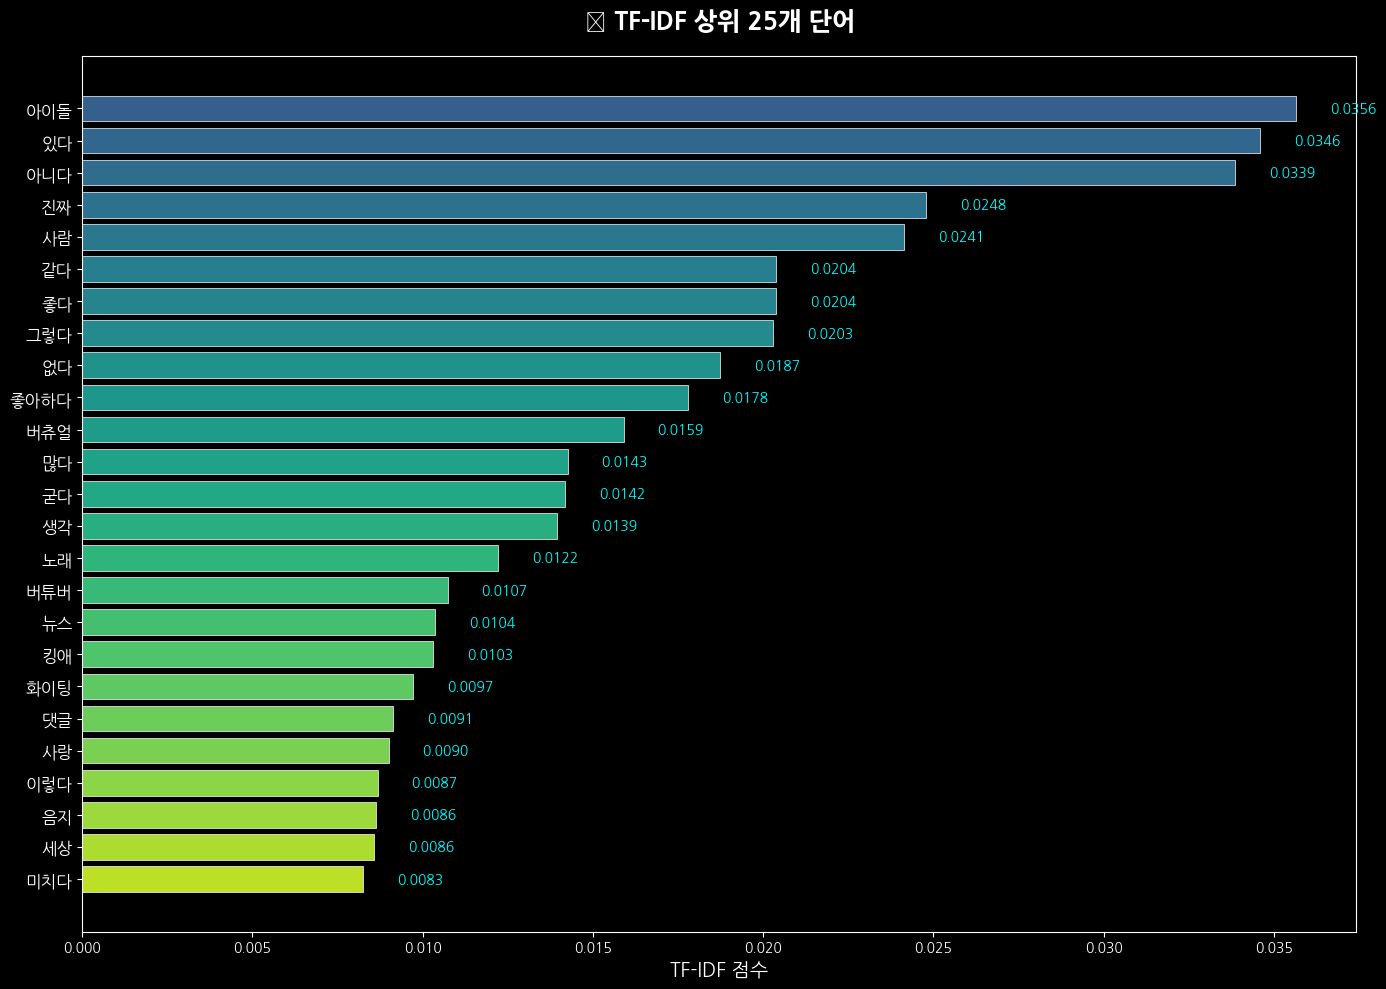

In [29]:
# 상위 25개 단어 시각화
top_n = 25
top_tfidf = df_tfidf.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))

# 그라데이션 색상
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))

bars = ax.barh(range(top_n), top_tfidf['TF-IDF'].values[::-1], 
               color=colors[::-1], edgecolor='white', linewidth=0.5)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_tfidf['단어'].values[::-1], fontsize=12)
ax.set_xlabel('TF-IDF 점수', fontsize=14)
ax.set_title('📊 TF-IDF 상위 25개 단어', fontsize=18, fontweight='bold', pad=20)

# 값 표시
for bar, val in zip(bars, top_tfidf['TF-IDF'].values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10, color='cyan')

plt.tight_layout()
plt.savefig('tfidf_top_words.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 4. N-gram 분석

### 4.1 Unigram, Bigram, Trigram 추출

In [30]:
def extract_ngrams(tokenized_docs, n):
    """토큰화된 문서에서 n-gram 추출"""
    ngrams = []
    for tokens in tokenized_docs:
        if len(tokens) >= n:
            for i in range(len(tokens) - n + 1):
                ngram = tuple(tokens[i:i+n])
                ngrams.append(ngram)
    return ngrams

# N-gram 추출
unigrams = extract_ngrams(tokenized_comments, 1)
bigrams = extract_ngrams(tokenized_comments, 2)
trigrams = extract_ngrams(tokenized_comments, 3)

# 빈도수 계산
unigram_freq = Counter(unigrams)
bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

print(f"📊 N-gram 통계")
print(f"   - Unigram (1-gram): {len(unigram_freq):,}개 고유 패턴, 총 {len(unigrams):,}개")
print(f"   - Bigram (2-gram): {len(bigram_freq):,}개 고유 패턴, 총 {len(bigrams):,}개")
print(f"   - Trigram (3-gram): {len(trigram_freq):,}개 고유 패턴, 총 {len(trigrams):,}개")

📊 N-gram 통계
   - Unigram (1-gram): 4,981개 고유 패턴, 총 28,216개
   - Bigram (2-gram): 19,418개 고유 패턴, 총 23,990개
   - Trigram (3-gram): 19,970개 고유 패턴, 총 20,459개


### 4.2 N-gram 빈도 DataFrame 생성

In [31]:
# Unigram DataFrame
df_unigram = pd.DataFrame([
    {'N-gram': gram[0], '빈도': count} 
    for gram, count in unigram_freq.most_common(50)
])

# Bigram DataFrame
df_bigram = pd.DataFrame([
    {'N-gram': ' + '.join(gram), '빈도': count, '단어1': gram[0], '단어2': gram[1]} 
    for gram, count in bigram_freq.most_common(50)
])

# Trigram DataFrame
df_trigram = pd.DataFrame([
    {'N-gram': ' + '.join(gram), '빈도': count} 
    for gram, count in trigram_freq.most_common(50)
])

print("🔤 상위 15개 Unigram:")
display(df_unigram.head(15))

🔤 상위 15개 Unigram:


,N-gram,빈도
0,아이돌,787
1,있다,778
2,아니다,572
3,사람,505
4,같다,356
5,없다,352
6,좋다,343
7,좋아하다,310
8,진짜,293
9,그렇다,289


In [32]:
print("🔤🔤 상위 15개 Bigram:")
display(df_bigram.head(15))

🔤🔤 상위 15개 Bigram:


,N-gram,빈도,단어1,단어2
0,버츄얼 + 아이돌,91,버츄얼,아이돌
1,사람 + 있다,53,사람,있다
2,노래 + 좋다,49,노래,좋다
3,모두 + 준비,34,모두,준비
4,사람 + 많다,29,사람,많다
5,버추 + 아이돌,29,버추,아이돌
6,좋아하다 + 사람,28,좋아하다,사람
7,메타 + 버스,28,메타,버스
8,있다 + 사람,26,있다,사람
9,아이돌 + 좋아하다,25,아이돌,좋아하다


In [33]:
print("🔤🔤🔤 상위 15개 Trigram:")
display(df_trigram.head(15))

🔤🔤🔤 상위 15개 Trigram:


,N-gram,빈도
0,진입 + 장벽 + 높다,10
1,모두 + 준비 + 깊다,8
2,광대 + 얼굴 + 보성,8
3,얼굴 + 보성 + 친구,8
4,보성 + 친구 + 희망이,8
5,친구 + 희망이 + 무시,8
6,준비 + 깊다 + 깃치,7
7,깊다 + 깃치 + 마을,7
8,버츄얼 + 아이돌 + 있다,6
9,좋아하다 + 사람 + 있다,6


### 4.3 N-gram 빈도 비교 시각화

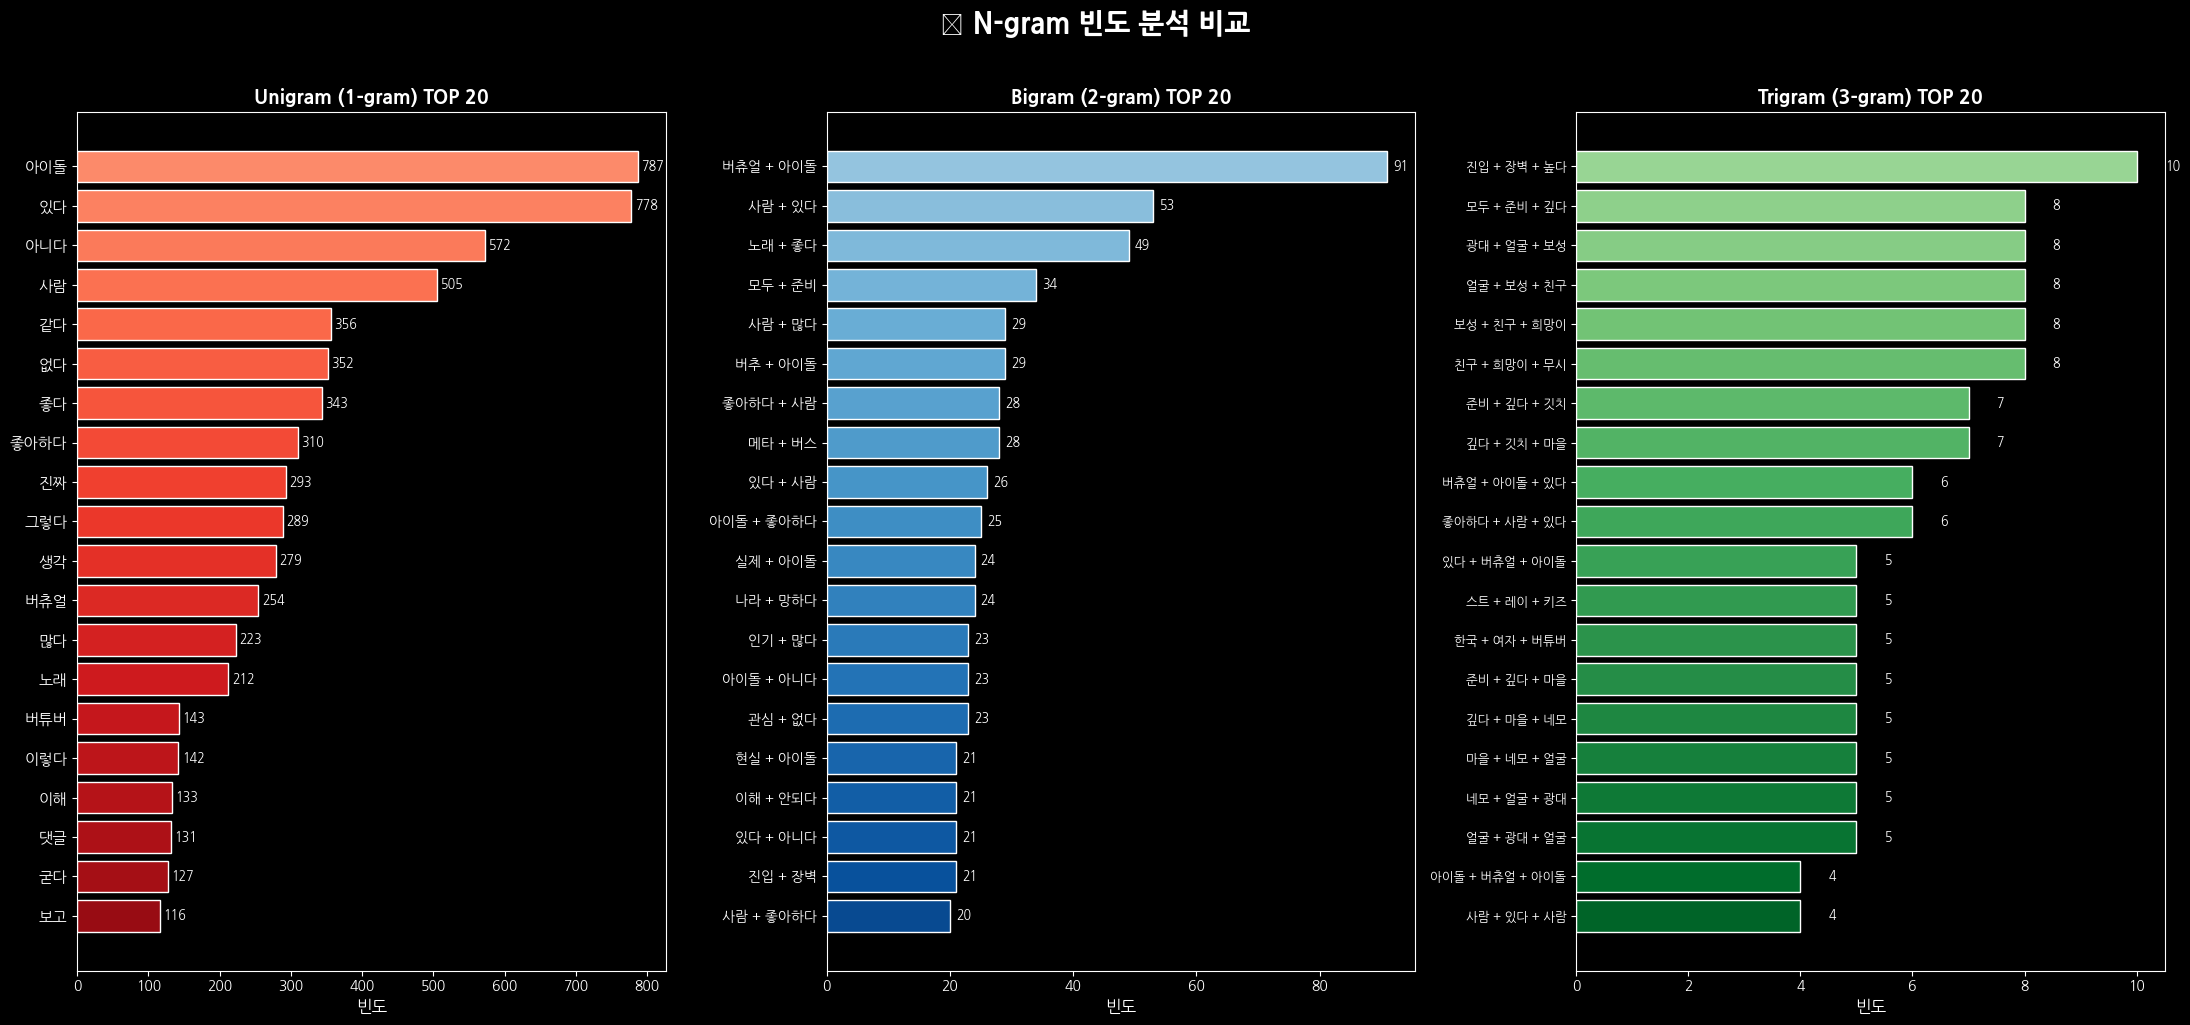

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Unigram
top_uni = df_unigram.head(20)
colors1 = plt.cm.Reds(np.linspace(0.4, 0.9, 20))
axes[0].barh(range(20), top_uni['빈도'].values[::-1], color=colors1[::-1], edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_uni['N-gram'].values[::-1], fontsize=11)
axes[0].set_title('Unigram (1-gram) TOP 20', fontsize=14, fontweight='bold')
axes[0].set_xlabel('빈도', fontsize=12)
for i, v in enumerate(top_uni['빈도'].values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9, color='white')

# Bigram
top_bi = df_bigram.head(20)
colors2 = plt.cm.Blues(np.linspace(0.4, 0.9, 20))
axes[1].barh(range(20), top_bi['빈도'].values[::-1], color=colors2[::-1], edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_bi['N-gram'].values[::-1], fontsize=10)
axes[1].set_title('Bigram (2-gram) TOP 20', fontsize=14, fontweight='bold')
axes[1].set_xlabel('빈도', fontsize=12)
for i, v in enumerate(top_bi['빈도'].values[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9, color='white')

# Trigram
top_tri = df_trigram.head(20)
colors3 = plt.cm.Greens(np.linspace(0.4, 0.9, 20))
axes[2].barh(range(20), top_tri['빈도'].values[::-1], color=colors3[::-1], edgecolor='white')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top_tri['N-gram'].values[::-1], fontsize=9)
axes[2].set_title('Trigram (3-gram) TOP 20', fontsize=14, fontweight='bold')
axes[2].set_xlabel('빈도', fontsize=12)
for i, v in enumerate(top_tri['빈도'].values[::-1]):
    axes[2].text(v + 0.5, i, str(v), va='center', fontsize=9, color='white')

plt.suptitle('📊 N-gram 빈도 분석 비교', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ngram_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 5. N-gram TF-IDF 분석

In [35]:
# Bigram TF-IDF
tfidf_bigram = TfidfVectorizer(
    ngram_range=(2, 2),
    max_features=200,
    min_df=1,
    max_df=0.95
)

tfidf_bigram_matrix = tfidf_bigram.fit_transform(documents)
bigram_features = tfidf_bigram.get_feature_names_out()
bigram_scores = np.array(tfidf_bigram_matrix.mean(axis=0)).flatten()

df_bigram_tfidf = pd.DataFrame({
    'Bigram': bigram_features,
    'TF-IDF': bigram_scores
}).sort_values('TF-IDF', ascending=False).head(30)

print("🔤🔤 Bigram TF-IDF 상위 30개:")
df_bigram_tfidf

🔤🔤 Bigram TF-IDF 상위 30개:


,Bigram,TF-IDF
47,버츄얼 아이돌,0.011414
24,노래 좋다,0.008495
34,모두 준비,0.006678
64,사람 있다,0.006610
22,나라 망하다,0.004995
59,사람 많다,0.004570
140,인기 많다,0.004414
124,엔카 이브,0.004413
10,관심 없다,0.004269
45,버추 아이돌,0.004139


In [36]:
# Trigram TF-IDF
tfidf_trigram = TfidfVectorizer(
    ngram_range=(3, 3),
    max_features=200,
    min_df=1,
    max_df=0.95
)

tfidf_trigram_matrix = tfidf_trigram.fit_transform(documents)
trigram_features = tfidf_trigram.get_feature_names_out()
trigram_scores = np.array(tfidf_trigram_matrix.mean(axis=0)).flatten()

df_trigram_tfidf = pd.DataFrame({
    'Trigram': trigram_features,
    'TF-IDF': trigram_scores
}).sort_values('TF-IDF', ascending=False).head(30)

print("🔤🔤🔤 Trigram TF-IDF 상위 30개:")
df_trigram_tfidf

🔤🔤🔤 Trigram TF-IDF 상위 30개:


,Trigram,TF-IDF
176,진입 장벽 높다,0.002114
37,버츄얼 아이돌 있다,0.001341
171,좋아하다 사람 있다,0.000975
170,좋아하다 사람 많다,0.000947
38,버츄얼 아이돌 좋아하다,0.000813
68,아이돌 버츄얼 아이돌,0.000773
1,같다 버츄얼 아이돌,0.000744
77,아이돌 좋아하다 사람,0.000736
141,있다 버츄얼 아이돌,0.000732
181,충성 높다 팬층,0.000710


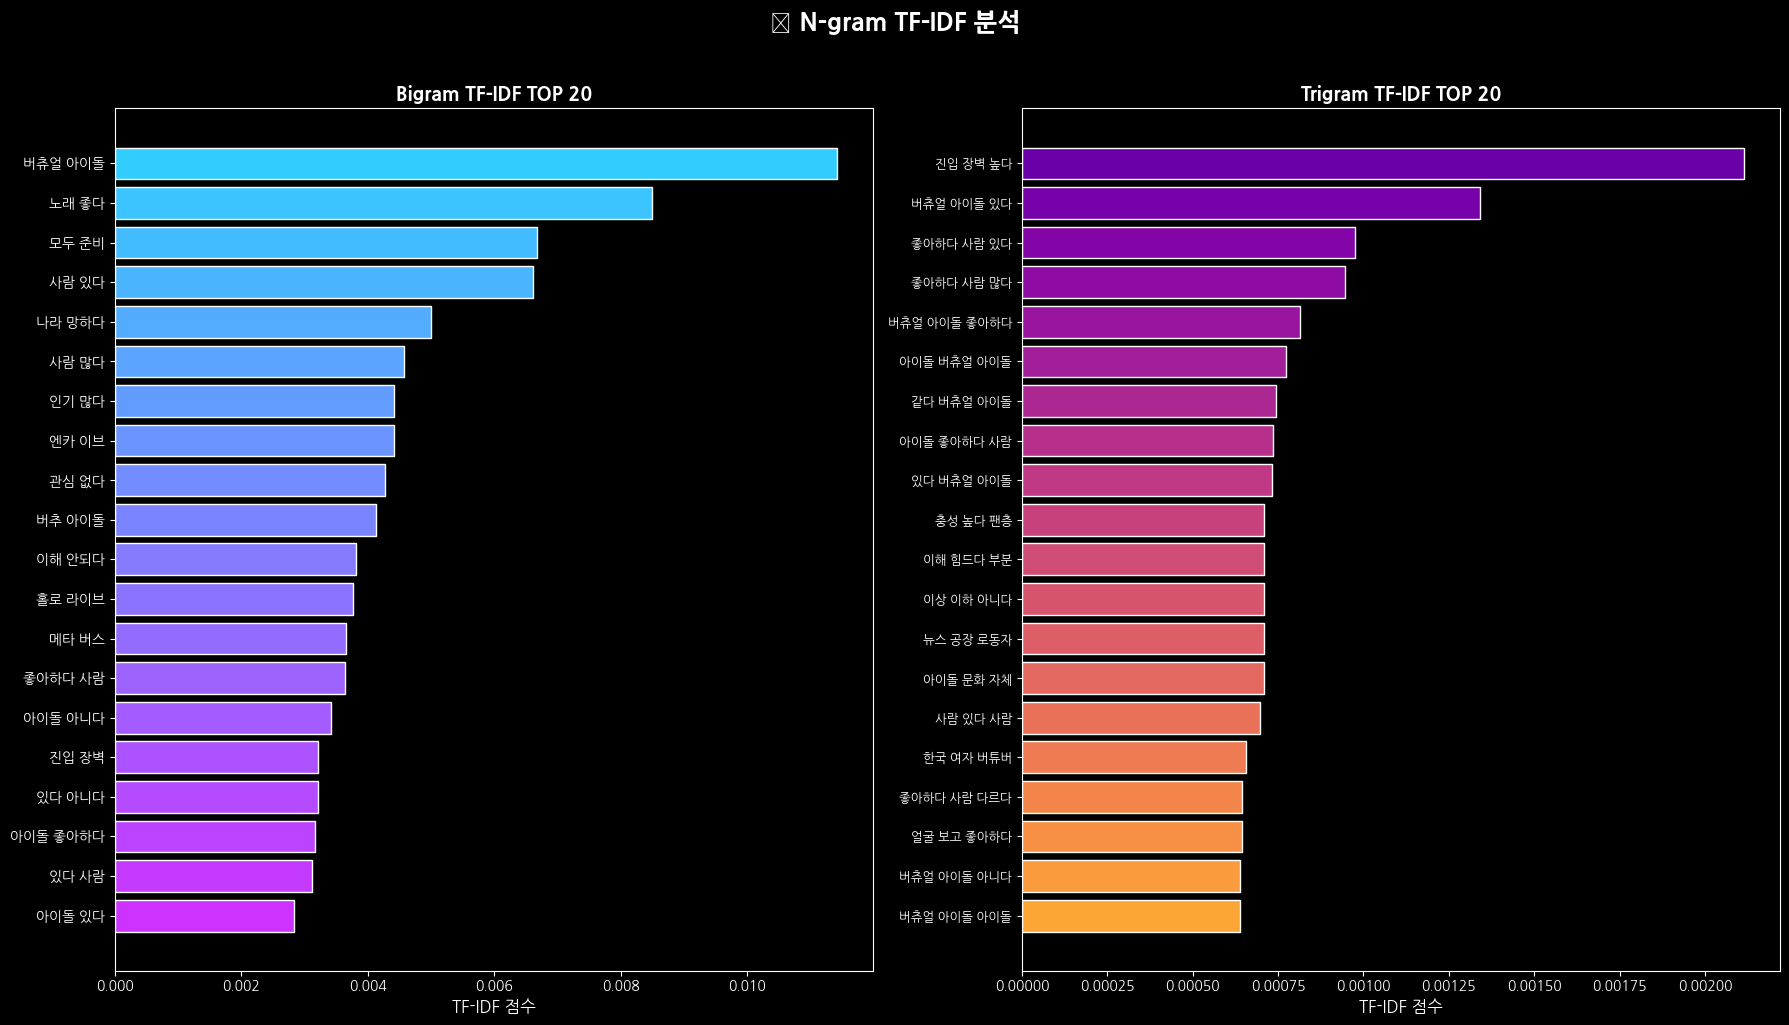

In [37]:
# Bigram & Trigram TF-IDF 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Bigram TF-IDF
top_bi_tfidf = df_bigram_tfidf.head(20)
colors1 = plt.cm.cool(np.linspace(0.2, 0.8, 20))
axes[0].barh(range(20), top_bi_tfidf['TF-IDF'].values[::-1], color=colors1[::-1], edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_bi_tfidf['Bigram'].values[::-1], fontsize=10)
axes[0].set_title('Bigram TF-IDF TOP 20', fontsize=14, fontweight='bold')
axes[0].set_xlabel('TF-IDF 점수', fontsize=12)

# Trigram TF-IDF
top_tri_tfidf = df_trigram_tfidf.head(20)
colors2 = plt.cm.plasma(np.linspace(0.2, 0.8, 20))
axes[1].barh(range(20), top_tri_tfidf['TF-IDF'].values[::-1], color=colors2[::-1], edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_tri_tfidf['Trigram'].values[::-1], fontsize=9)
axes[1].set_title('Trigram TF-IDF TOP 20', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TF-IDF 점수', fontsize=12)

plt.suptitle('📊 N-gram TF-IDF 분석', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ngram_tfidf.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 6. 단어 동시출현 (Co-occurrence) 분석

In [38]:
def build_cooccurrence(tokenized_docs, min_freq=3):
    """동시출현 빈도 계산"""
    # 최소 빈도 이상인 단어만 선택
    vocab = {word for word, count in word_freq.items() if count >= min_freq}
    
    # 동시출현 카운트
    cooccurrence = defaultdict(int)
    for tokens in tokenized_docs:
        filtered_tokens = [t for t in tokens if t in vocab]
        unique_tokens = list(set(filtered_tokens))
        for w1, w2 in combinations(unique_tokens, 2):
            pair = tuple(sorted([w1, w2]))
            cooccurrence[pair] += 1
    
    return cooccurrence, vocab

# 동시출현 계산
cooccurrence, vocab = build_cooccurrence(tokenized_comments, min_freq=3)

# DataFrame 변환
df_cooc = pd.DataFrame([
    {'단어1': pair[0], '단어2': pair[1], '동시출현': count}
    for pair, count in cooccurrence.items()
]).sort_values('동시출현', ascending=False).reset_index(drop=True)

print(f"📊 동시출현 분석 결과")
print(f"   - 분석 단어 수: {len(vocab):,}개")
print(f"   - 단어 쌍 수: {len(cooccurrence):,}개")
print(f"\n🔗 상위 30개 동시출현 단어 쌍:")
df_cooc.head(30)

📊 동시출현 분석 결과
   - 분석 단어 수: 1,598개
   - 단어 쌍 수: 82,694개

🔗 상위 30개 동시출현 단어 쌍:


,단어1,단어2,동시출현
0,아이돌,있다,165
1,사람,있다,151
2,아니다,있다,118
3,버츄얼,아이돌,113
4,아니다,아이돌,109
5,사람,아니다,104
6,사람,아이돌,102
7,생각,있다,99
8,없다,있다,97
9,같다,있다,97


### 6.1 동시출현 히트맵

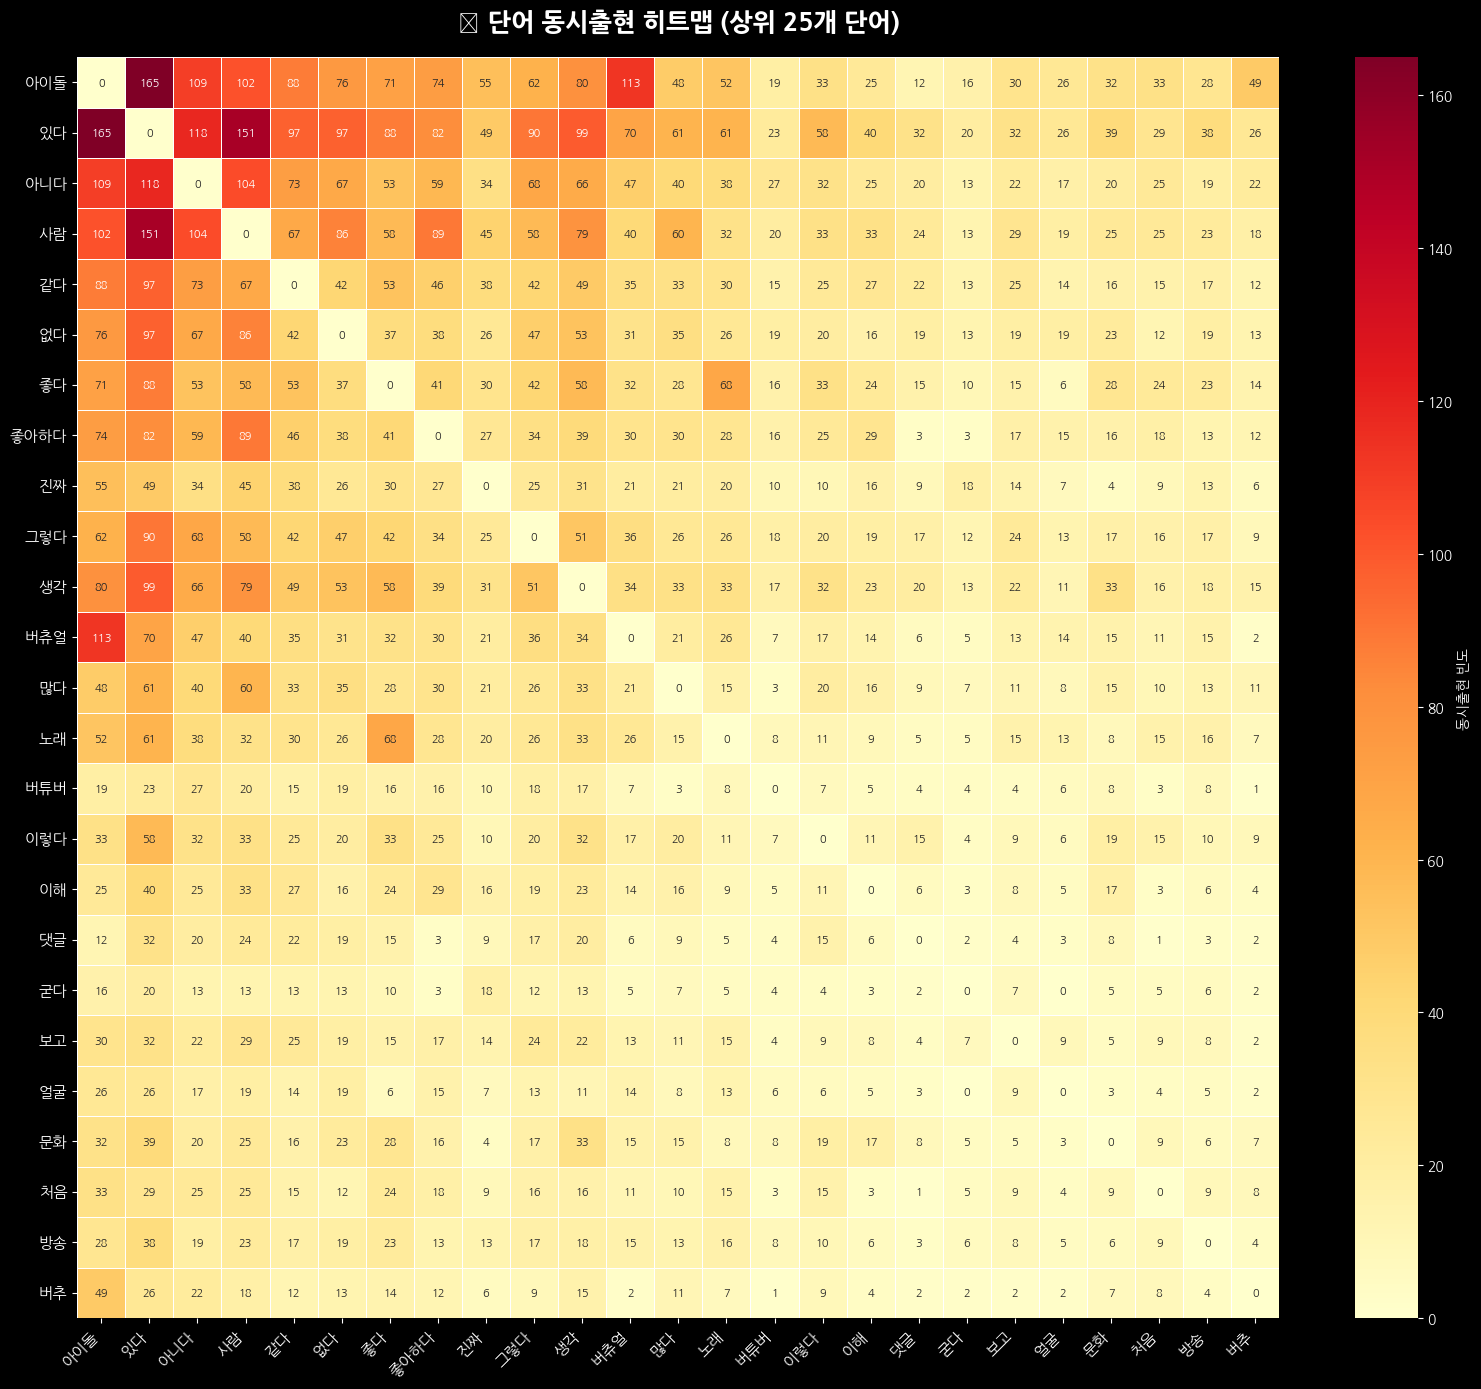

In [39]:
# 상위 빈도 단어 선택 (히트맵용)
top_words_for_heatmap = [word for word, _ in word_freq.most_common(25)]

# 동시출현 행렬 생성
matrix_size = len(top_words_for_heatmap)
cooc_matrix = np.zeros((matrix_size, matrix_size))

for (w1, w2), count in cooccurrence.items():
    if w1 in top_words_for_heatmap and w2 in top_words_for_heatmap:
        i, j = top_words_for_heatmap.index(w1), top_words_for_heatmap.index(w2)
        cooc_matrix[i][j] = count
        cooc_matrix[j][i] = count

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(cooc_matrix, 
            xticklabels=top_words_for_heatmap, 
            yticklabels=top_words_for_heatmap,
            cmap='YlOrRd',
            annot=True,
            fmt='.0f',
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'label': '동시출현 빈도'})

ax.set_title('🔥 단어 동시출현 히트맵 (상위 25개 단어)', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 7. PMI (Pointwise Mutual Information) 연관도 분석

In [40]:
def calculate_pmi(tokenized_docs, word_freq, min_freq=3, min_cooc=2):
    """PMI (Pointwise Mutual Information) 계산"""
    total_words = sum(word_freq.values())
    n_docs = len(tokenized_docs)
    
    # 동시출현 빈도
    cooc_freq = defaultdict(int)
    for tokens in tokenized_docs:
        unique_tokens = list(set(tokens))
        for w1, w2 in combinations(unique_tokens, 2):
            pair = tuple(sorted([w1, w2]))
            cooc_freq[pair] += 1
    
    # PMI 계산
    pmi_scores = []
    
    for (w1, w2), cooc_count in cooc_freq.items():
        if (word_freq[w1] >= min_freq and 
            word_freq[w2] >= min_freq and 
            cooc_count >= min_cooc):
            
            # P(w1, w2) - 동시출현 확률
            p_w1_w2 = cooc_count / n_docs
            # P(w1) - 단어1 확률
            p_w1 = word_freq[w1] / total_words
            # P(w2) - 단어2 확률
            p_w2 = word_freq[w2] / total_words
            
            # PMI = log2(P(w1,w2) / (P(w1) * P(w2)))
            if p_w1 * p_w2 > 0:
                pmi = np.log2(p_w1_w2 / (p_w1 * p_w2))
                
                # NPMI (Normalized PMI) = PMI / -log2(P(w1,w2))
                npmi = pmi / (-np.log2(p_w1_w2)) if p_w1_w2 > 0 else 0
                
                pmi_scores.append({
                    '단어1': w1,
                    '단어2': w2,
                    'PMI': pmi,
                    'NPMI': npmi,
                    '동시출현': cooc_count,
                    '단어1_빈도': word_freq[w1],
                    '단어2_빈도': word_freq[w2]
                })
    
    return pd.DataFrame(pmi_scores)

# PMI 계산
df_pmi = calculate_pmi(tokenized_comments, word_freq, min_freq=3, min_cooc=2)
df_pmi = df_pmi.sort_values('PMI', ascending=False).reset_index(drop=True)

print(f"📊 PMI 분석 결과: {len(df_pmi):,}개 단어 쌍")
print(f"\n🔗 PMI 상위 30개 연관 단어 쌍 (높은 연관도):")
df_pmi.head(30)

📊 PMI 분석 결과: 19,315개 단어 쌍

🔗 PMI 상위 30개 연관 단어 쌍 (높은 연관도):


,단어1,단어2,PMI,NPMI,동시출현,단어1_빈도,단어2_빈도
0,과대,포장,15.938412,1.523732,3,3,3
1,레드,오션,15.938412,1.523732,3,3,3
2,도가니,흥분,15.938412,1.523732,3,3,3
3,로켓,펀쳐,15.523375,1.484054,3,4,3
4,남혐,버튜버판,15.523375,1.484054,3,4,3
5,공장,로동자,15.523375,1.484054,3,4,3
6,음색,청순,15.523375,1.484054,3,3,4
7,요정,음색,15.523375,1.484054,3,4,3
8,펀쳐,해커,15.523375,1.484054,3,3,4
9,얼돌,클럽,15.353450,1.390072,2,3,3


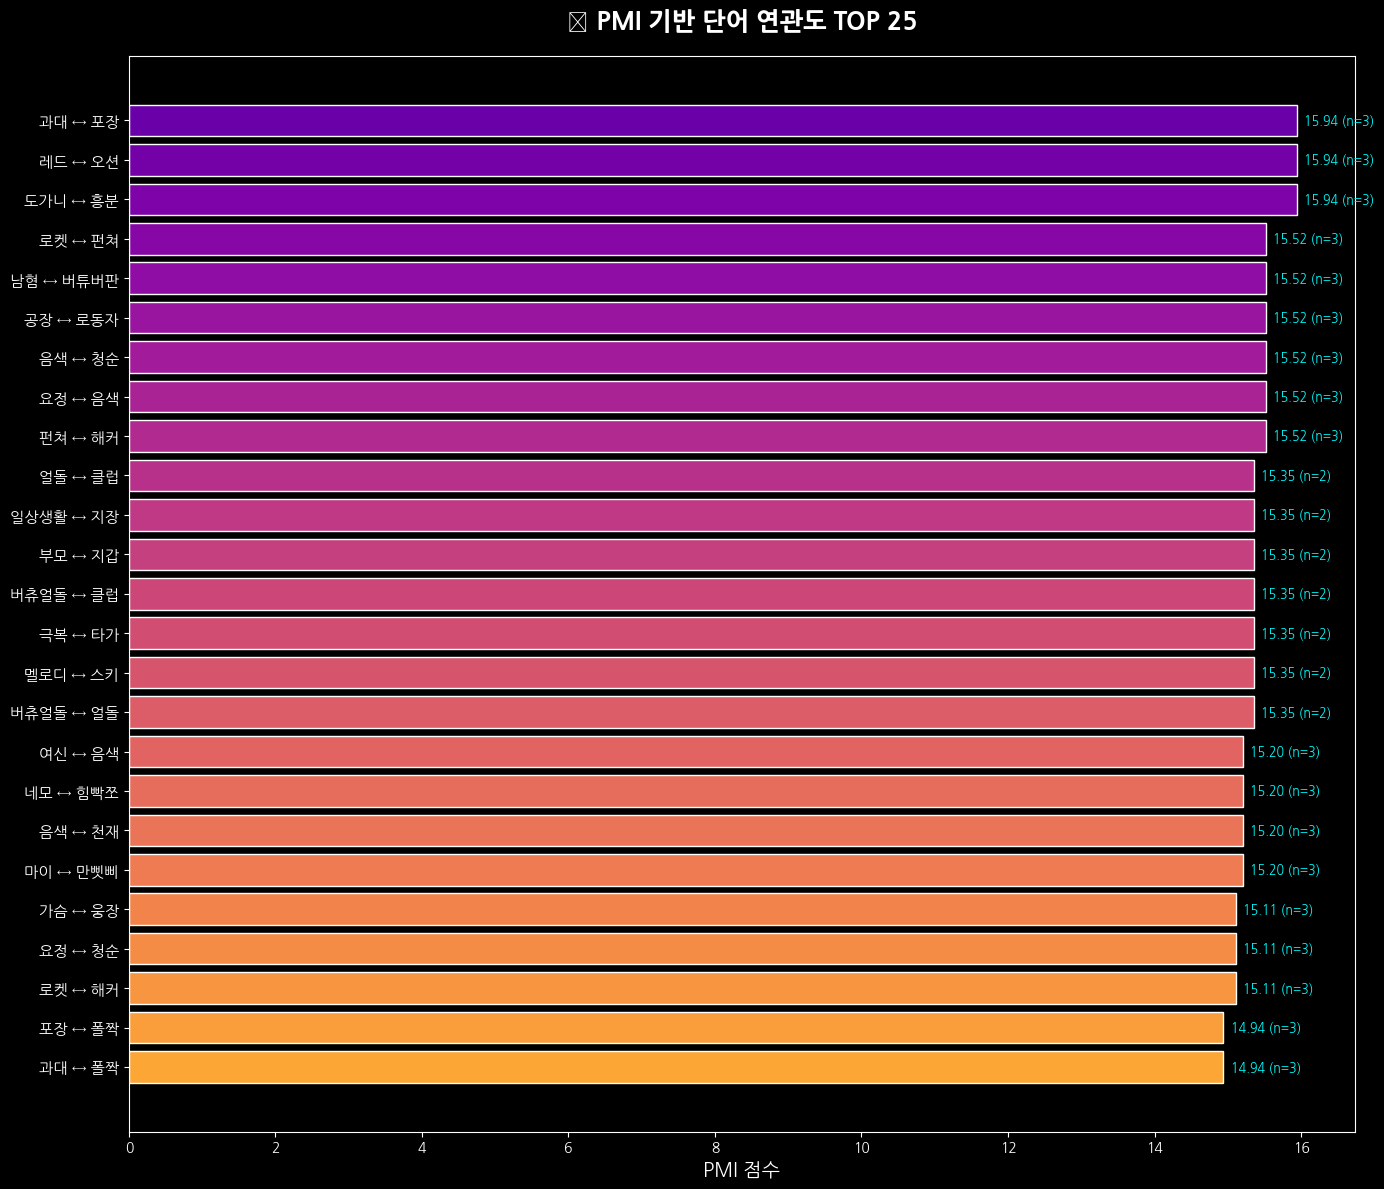

In [41]:
# PMI 시각화
top_pmi = df_pmi.head(25).copy()
top_pmi['단어쌍'] = top_pmi['단어1'] + ' ↔ ' + top_pmi['단어2']

fig, ax = plt.subplots(figsize=(14, 12))

colors = plt.cm.plasma(np.linspace(0.2, 0.8, 25))
bars = ax.barh(range(25), top_pmi['PMI'].values[::-1], color=colors[::-1], edgecolor='white')

ax.set_yticks(range(25))
ax.set_yticklabels(top_pmi['단어쌍'].values[::-1], fontsize=11)
ax.set_xlabel('PMI 점수', fontsize=14)
ax.set_title('🔗 PMI 기반 단어 연관도 TOP 25', fontsize=18, fontweight='bold', pad=20)

# 값 표시
for bar, val, cooc in zip(bars, top_pmi['PMI'].values[::-1], top_pmi['동시출현'].values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f} (n={cooc})', va='center', fontsize=9, color='cyan')

plt.tight_layout()
plt.savefig('pmi_association.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 8. 연관 네트워크 그래프 시각화

### 8.1 동시출현 기반 네트워크

In [42]:
# 네트워크 그래프 생성
G_cooc = nx.Graph()

# 상위 동시출현 쌍으로 엣지 추가 (상위 80개)
top_cooc = df_cooc.head(80)

for _, row in top_cooc.iterrows():
    G_cooc.add_edge(row['단어1'], row['단어2'], weight=row['동시출현'])

# 노드 크기 (빈도 기반)
node_sizes = [word_freq.get(node, 1) * 5 for node in G_cooc.nodes()]

# 엣지 가중치
edge_weights = [G_cooc[u][v]['weight'] * 0.3 for u, v in G_cooc.edges()]

print(f"📊 동시출현 네트워크 구성")
print(f"   - 노드 수: {G_cooc.number_of_nodes()}")
print(f"   - 엣지 수: {G_cooc.number_of_edges()}")

📊 동시출현 네트워크 구성
   - 노드 수: 25
   - 엣지 수: 80


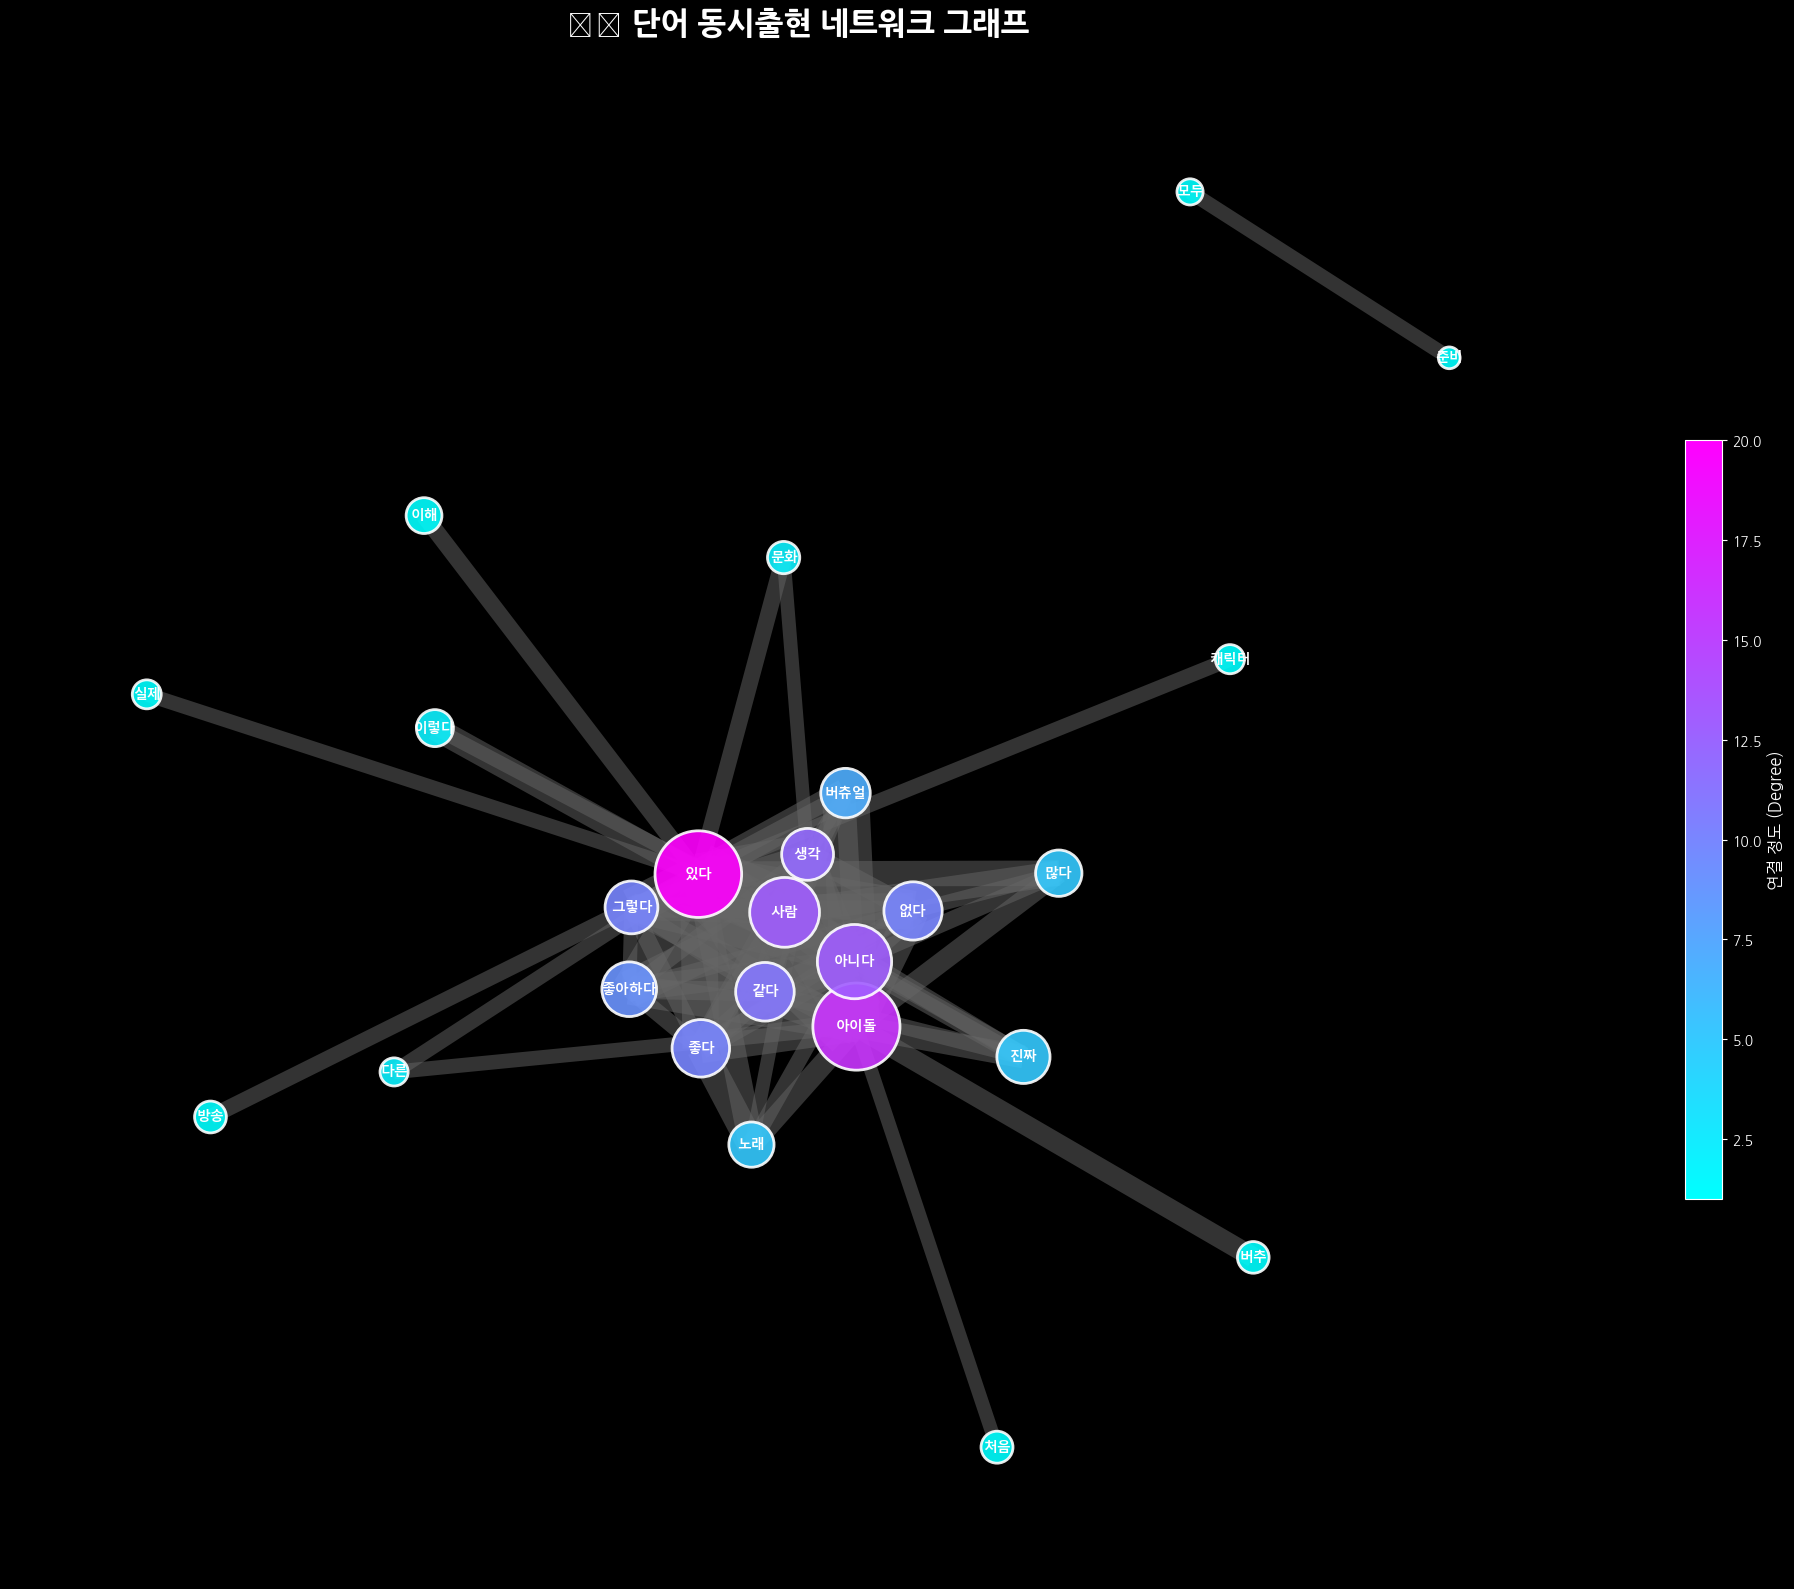

In [48]:
# 동시출현 네트워크 시각화
fig, ax = plt.subplots(figsize=(20, 16))

# 레이아웃
pos = nx.spring_layout(G_cooc, k=2, iterations=50, seed=42)

# 노드 색상 (연결 정도)
degrees = dict(G_cooc.degree())
node_colors = [degrees[node] for node in G_cooc.nodes()]

# 엣지 그리기
nx.draw_networkx_edges(G_cooc, pos, 
                       width=edge_weights,
                       alpha=0.5, 
                       edge_color='#666666',
                       ax=ax)

# 노드 그리기
nodes = nx.draw_networkx_nodes(G_cooc, pos,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.cool,
                               alpha=0.9,
                               edgecolors='white',
                               linewidths=2,
                               ax=ax)

# 레이블
nx.draw_networkx_labels(G_cooc, pos, font_size=10, font_color='white', 
                        font_weight='bold', font_family='Malgun Gothic', ax=ax)

ax.set_title('🕸️ 단어 동시출현 네트워크 그래프', fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# 컬러바
sm = plt.cm.ScalarMappable(cmap=plt.cm.cool, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label('연결 정도 (Degree)', fontsize=12)

plt.tight_layout()
plt.savefig('cooccurrence_network.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

### 8.2 PMI 기반 연관 네트워크

In [44]:
# PMI 기반 네트워크 (양의 PMI, 동시출현 3회 이상)
G_pmi = nx.Graph()

top_pmi_pairs = df_pmi[(df_pmi['PMI'] > 0) & (df_pmi['동시출현'] >= 3)].head(60)

for _, row in top_pmi_pairs.iterrows():
    G_pmi.add_edge(row['단어1'], row['단어2'], weight=row['PMI'], cooc=row['동시출현'])

print(f"📊 PMI 네트워크 구성")
print(f"   - 노드 수: {G_pmi.number_of_nodes()}")
print(f"   - 엣지 수: {G_pmi.number_of_edges()}")

📊 PMI 네트워크 구성
   - 노드 수: 71
   - 엣지 수: 60


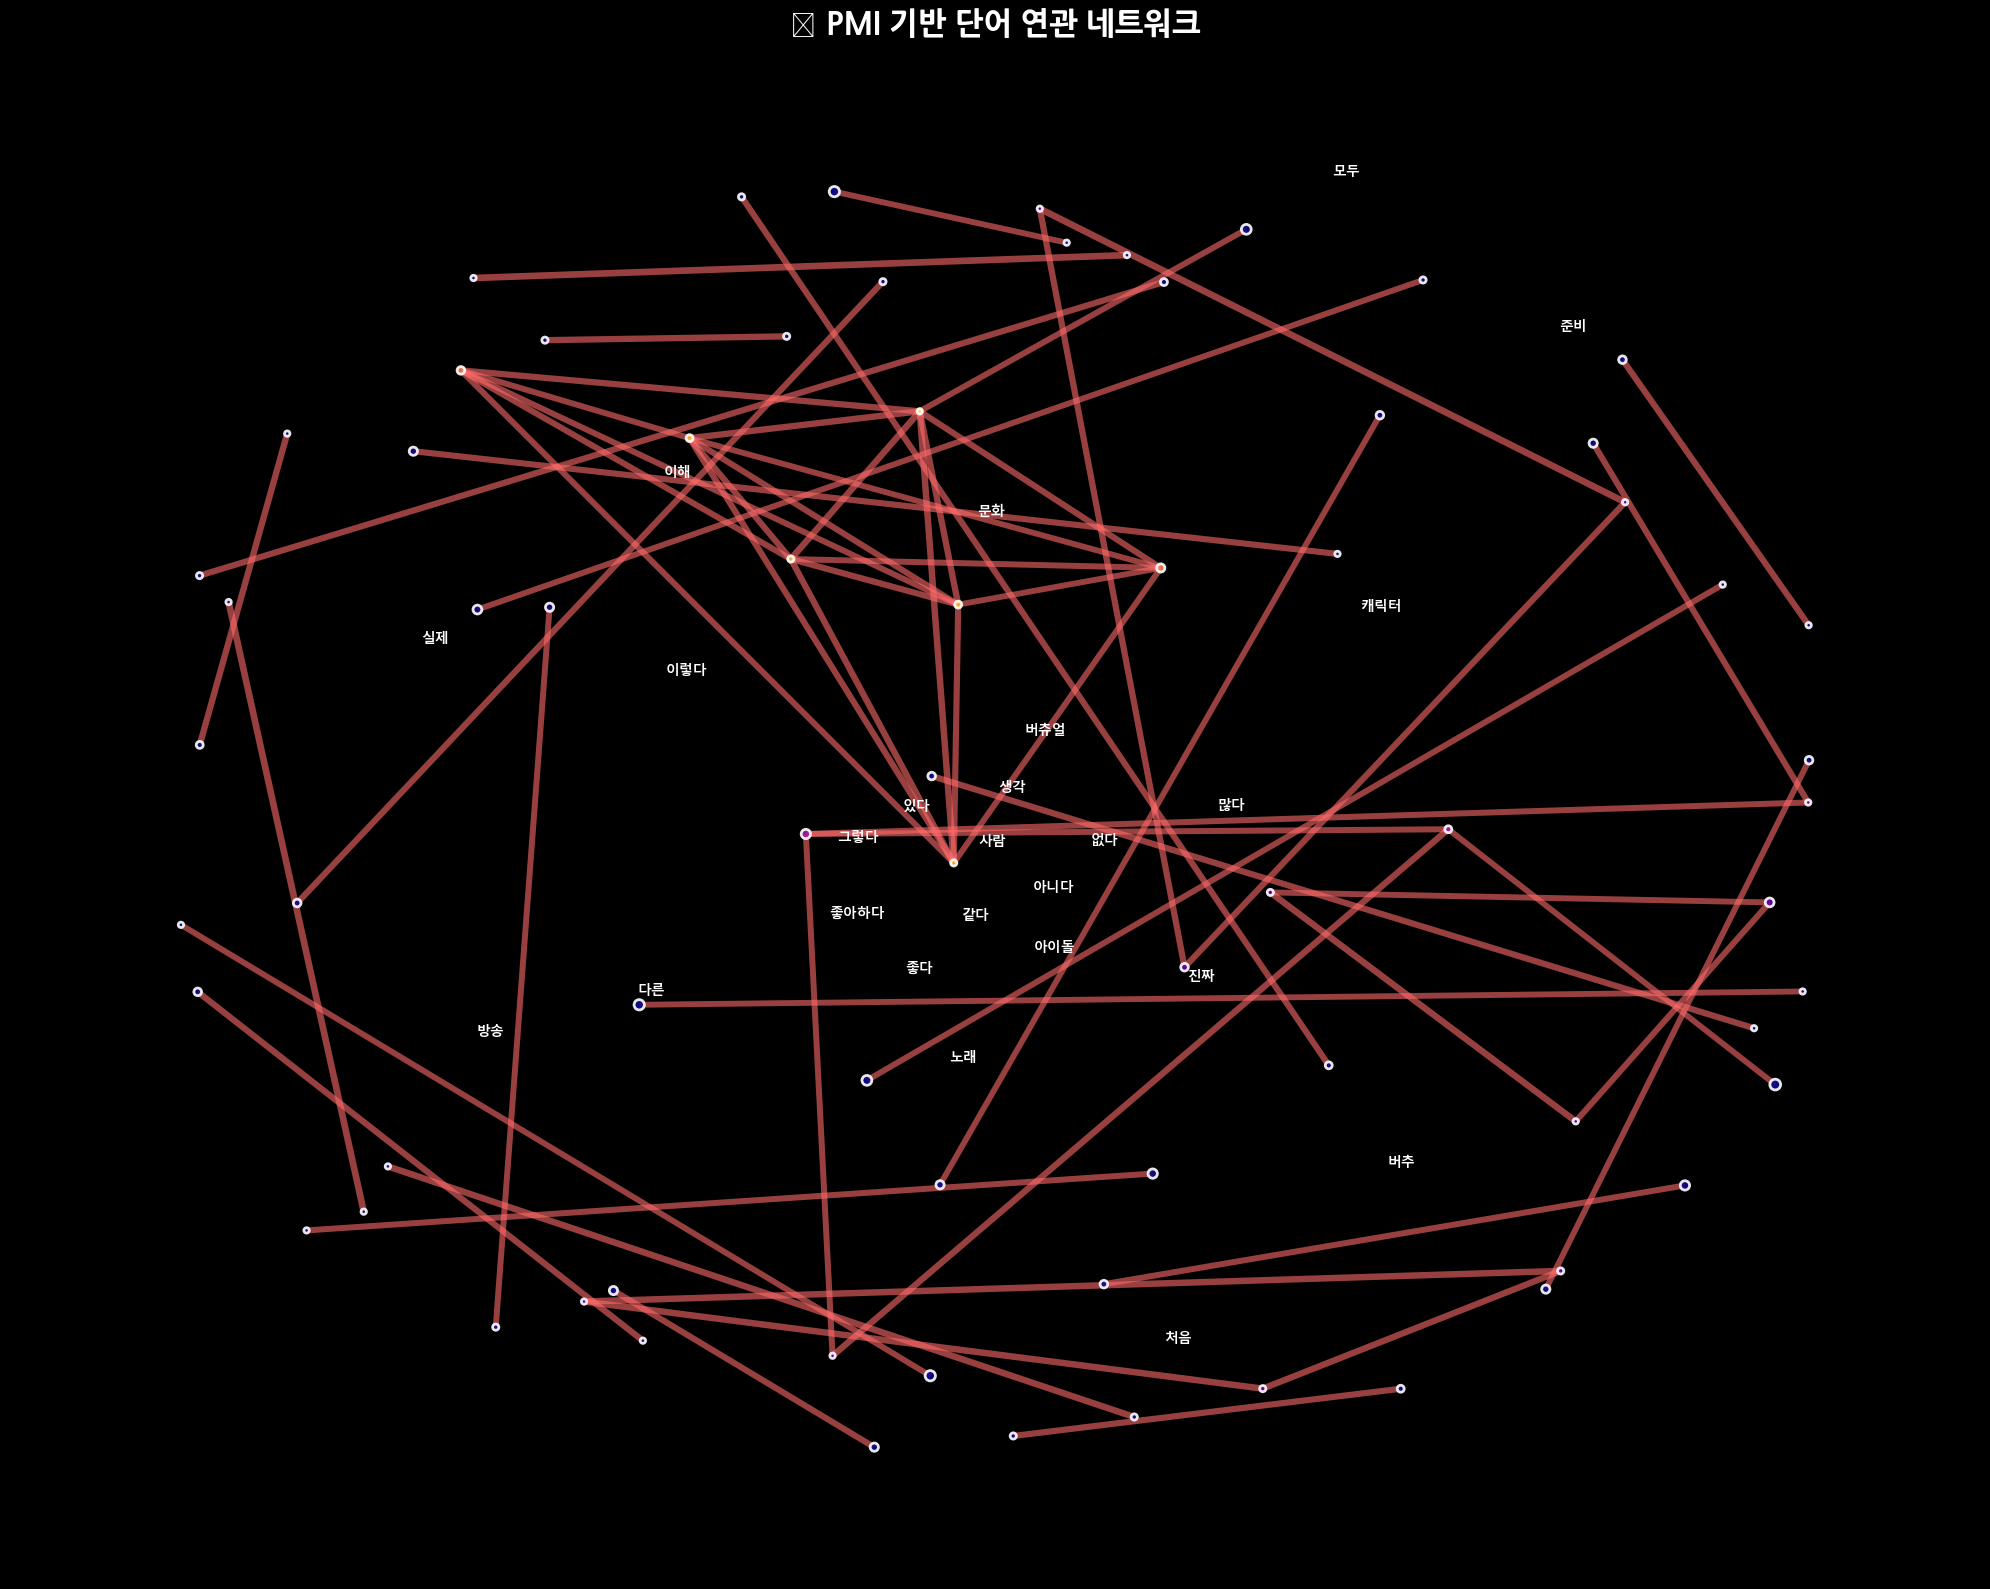

In [49]:
# PMI 네트워크 시각화
fig, ax = plt.subplots(figsize=(20, 16))

pos_pmi = nx.spring_layout(G_pmi, k=2.5, iterations=50, seed=42)

# 노드 크기
pmi_node_sizes = [word_freq.get(node, 1) * 5 for node in G_pmi.nodes()]

# 엣지 가중치 (PMI 기반)
pmi_edge_weights = [max(G_pmi[u][v]['weight'] * 0.3, 0.5) for u, v in G_pmi.edges()]

# 노드 색상
pmi_degrees = dict(G_pmi.degree())
pmi_node_colors = [pmi_degrees[node] for node in G_pmi.nodes()]

# 그리기
nx.draw_networkx_edges(G_pmi, pos_pmi, width=pmi_edge_weights, alpha=0.6, 
                       edge_color='#ff6b6b', ax=ax)

nx.draw_networkx_nodes(G_pmi, pos_pmi, node_size=pmi_node_sizes,
                       node_color=pmi_node_colors, cmap=plt.cm.plasma,
                       alpha=0.9, edgecolors='white', linewidths=2, ax=ax)

nx.draw_networkx_labels(G_cooc, pos, font_size=10, font_color='white', 
                        font_weight='bold', font_family='Malgun Gothic', ax=ax)

ax.set_title('🔗 PMI 기반 단어 연관 네트워크', fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('pmi_network.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

### 8.3 Bigram 방향 네트워크

In [46]:
# Bigram 네트워크 (방향 그래프 - 순서가 중요)
G_bigram = nx.DiGraph()

# 상위 Bigram으로 엣지 추가
for gram, count in bigram_freq.most_common(80):
    if count >= 2:
        G_bigram.add_edge(gram[0], gram[1], weight=count)

print(f"📊 Bigram 네트워크 구성")
print(f"   - 노드 수: {G_bigram.number_of_nodes()}")
print(f"   - 엣지 수: {G_bigram.number_of_edges()}")

📊 Bigram 네트워크 구성
   - 노드 수: 69
   - 엣지 수: 80


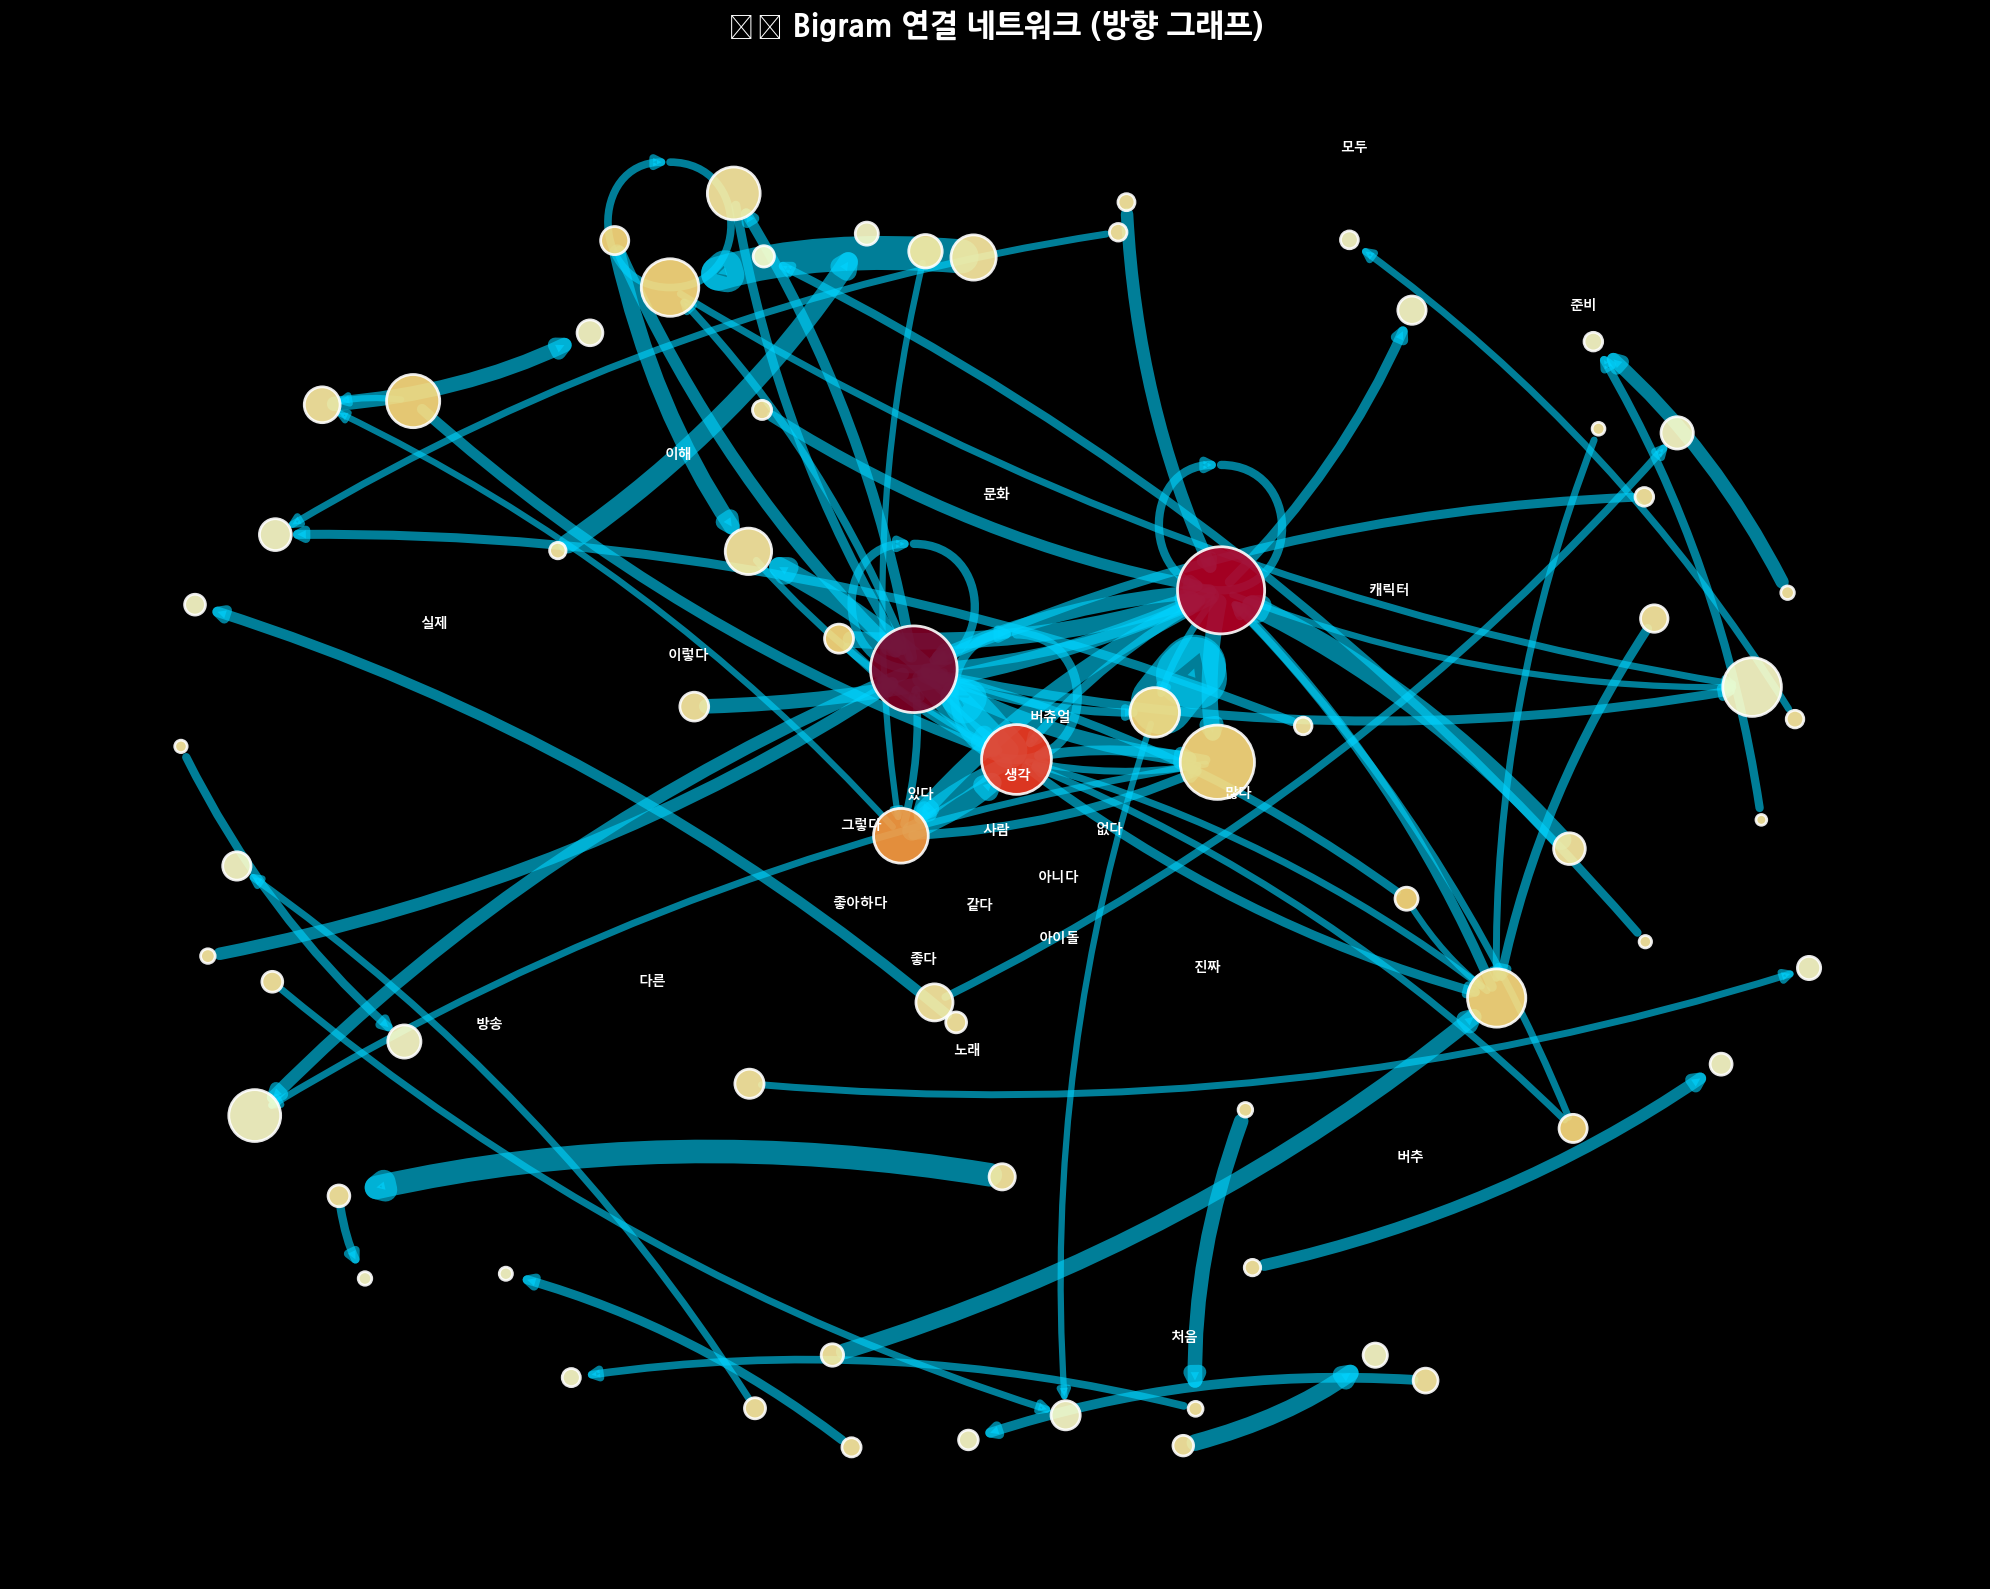

In [50]:
# Bigram 네트워크 시각화
fig, ax = plt.subplots(figsize=(20, 16))

pos_bi = nx.spring_layout(G_bigram, k=2, iterations=50, seed=42)

# 노드 크기
bi_node_sizes = [word_freq.get(node, 1) * 5 for node in G_bigram.nodes()]

# 엣지 가중치
bi_edge_weights = [G_bigram[u][v]['weight'] * 0.5 for u, v in G_bigram.edges()]

# 노드 색상 (out-degree 기준)
out_degrees = dict(G_bigram.out_degree())
bi_node_colors = [out_degrees.get(node, 0) for node in G_bigram.nodes()]

# 그리기
nx.draw_networkx_edges(G_bigram, pos_bi, 
                       width=bi_edge_weights, 
                       alpha=0.6,
                       edge_color='#00d4ff',
                       arrows=True,
                       arrowsize=15,
                       connectionstyle="arc3,rad=0.1",
                       ax=ax)

nx.draw_networkx_nodes(G_bigram, pos_bi, 
                       node_size=bi_node_sizes,
                       node_color=bi_node_colors,
                       cmap=plt.cm.YlOrRd,
                       alpha=0.9,
                       edgecolors='white',
                       linewidths=2,
                       ax=ax)

nx.draw_networkx_labels(G_cooc, pos, font_size=10, font_color='white', 
                        font_weight='bold', font_family='Malgun Gothic', ax=ax)

ax.set_title('🔤🔤 Bigram 연결 네트워크 (방향 그래프)', fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('bigram_network.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 9. TF-IDF 기반 문서 유사도

📊 문서 유사도 행렬 크기: (4226, 4226)


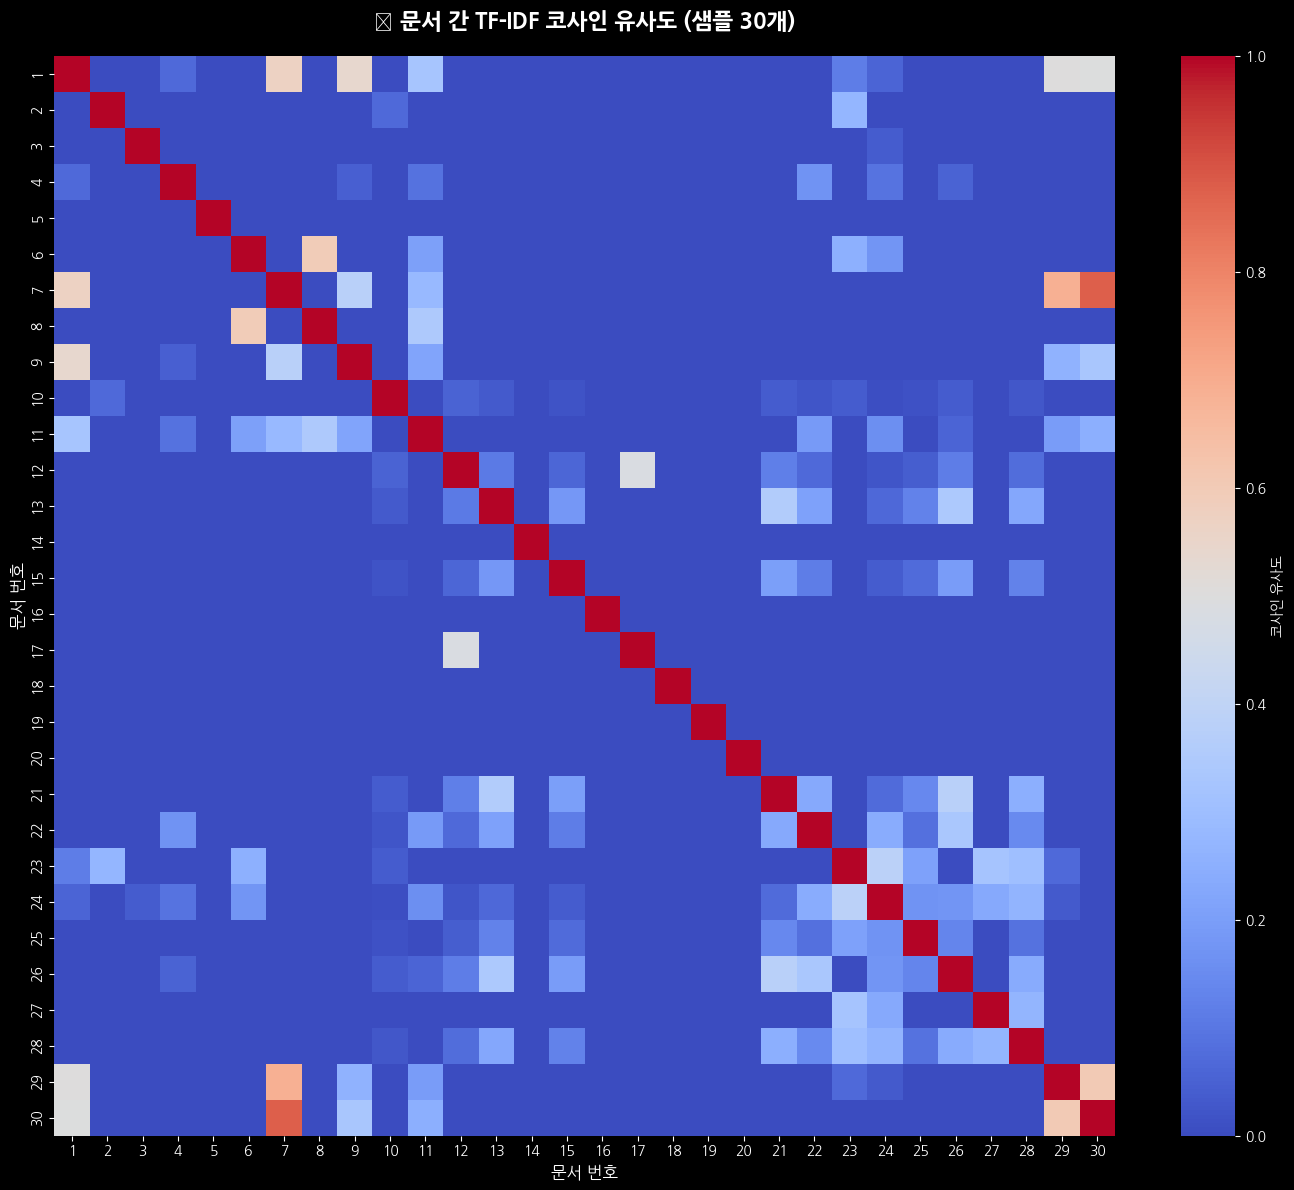

In [51]:
# 문서 간 코사인 유사도 계산
cosine_sim = cosine_similarity(tfidf_matrix)

print(f"📊 문서 유사도 행렬 크기: {cosine_sim.shape}")

# 히트맵 (샘플 30개 문서)
sample_size = min(30, len(documents))
sample_sim = cosine_sim[:sample_size, :sample_size]

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(sample_sim, 
            cmap='coolwarm',
            annot=False,
            xticklabels=range(1, sample_size+1),
            yticklabels=range(1, sample_size+1),
            ax=ax,
            cbar_kws={'label': '코사인 유사도'})

ax.set_title('📄 문서 간 TF-IDF 코사인 유사도 (샘플 30개)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('문서 번호', fontsize=12)
ax.set_ylabel('문서 번호', fontsize=12)

plt.tight_layout()
plt.savefig('document_similarity.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 10. 종합 대시보드

In [ ]:
fig = plt.figure(figsize=(26, 20))
fig.suptitle('🎭 버추얼 아이돌 TF-IDF & N-gram 분석 종합 대시보드', 
             fontsize=26, fontweight='bold', y=0.98)

# 1. TF-IDF 상위 단어
ax1 = fig.add_subplot(2, 3, 1)
top15_tfidf = df_tfidf.head(15)
colors1 = plt.cm.viridis(np.linspace(0.3, 0.9, 15))
ax1.barh(range(15), top15_tfidf['TF-IDF'].values[::-1], color=colors1[::-1], edgecolor='white')
ax1.set_yticks(range(15))
ax1.set_yticklabels(top15_tfidf['단어'].values[::-1], fontsize=11)
ax1.set_title('TF-IDF 상위 15개', fontsize=14, fontweight='bold')
ax1.set_xlabel('TF-IDF 점수')

# 2. Bigram 빈도
ax2 = fig.add_subplot(2, 3, 2)
top15_bi = df_bigram.head(15)
colors2 = plt.cm.Blues(np.linspace(0.4, 0.9, 15))
ax2.barh(range(15), top15_bi['빈도'].values[::-1], color=colors2[::-1], edgecolor='white')
ax2.set_yticks(range(15))
ax2.set_yticklabels(top15_bi['N-gram'].values[::-1], fontsize=10)
ax2.set_title('Bigram 빈도 TOP 15', fontsize=14, fontweight='bold')
ax2.set_xlabel('빈도')

# 3. PMI 연관도
ax3 = fig.add_subplot(2, 3, 3)
top15_pmi = df_pmi.head(15).copy()
top15_pmi['쌍'] = top15_pmi['단어1'] + '↔' + top15_pmi['단어2']
colors3 = plt.cm.plasma(np.linspace(0.3, 0.9, 15))
ax3.barh(range(15), top15_pmi['PMI'].values[::-1], color=colors3[::-1], edgecolor='white')
ax3.set_yticks(range(15))
ax3.set_yticklabels(top15_pmi['쌍'].values[::-1], fontsize=10)
ax3.set_title('PMI 연관도 TOP 15', fontsize=14, fontweight='bold')
ax3.set_xlabel('PMI 점수')

# 4. 동시출현 히트맵 (축소)
ax4 = fig.add_subplot(2, 3, 4)
top12_words = [word for word, _ in word_freq.most_common(12)]
small_matrix = np.zeros((12, 12))
for (w1, w2), count in cooccurrence.items():
    if w1 in top12_words and w2 in top12_words:
        i, j = top12_words.index(w1), top12_words.index(w2)
        small_matrix[i][j] = count
        small_matrix[j][i] = count
sns.heatmap(small_matrix, xticklabels=top12_words, yticklabels=top12_words,
            cmap='YlOrRd', annot=True, fmt='.0f', ax=ax4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax4.set_title('동시출현 히트맵', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. Trigram 빈도
ax5 = fig.add_subplot(2, 3, 5)
top15_tri = df_trigram.head(15)
colors5 = plt.cm.Greens(np.linspace(0.4, 0.9, 15))
ax5.barh(range(15), top15_tri['빈도'].values[::-1], color=colors5[::-1], edgecolor='white')
ax5.set_yticks(range(15))
ax5.set_yticklabels(top15_tri['N-gram'].values[::-1], fontsize=9)
ax5.set_title('Trigram 빈도 TOP 15', fontsize=14, fontweight='bold')
ax5.set_xlabel('빈도')

# 6. 네트워크 그래프 (간소화)
ax6 = fig.add_subplot(2, 3, 6)
G_small = nx.Graph()
for _, row in df_cooc.head(40).iterrows():
    G_small.add_edge(row['단어1'], row['단어2'], weight=row['동시출현'])
pos_small = nx.spring_layout(G_small, k=2, seed=42)
small_sizes = [word_freq.get(n, 1) * 3 for n in G_small.nodes()]
small_degrees = dict(G_small.degree())
small_colors = [small_degrees[n] for n in G_small.nodes()]
nx.draw_networkx_edges(G_small, pos_small, alpha=0.4, edge_color='gray', ax=ax6)
nx.draw_networkx_nodes(G_small, pos_small, node_size=small_sizes, 
                       node_color=small_colors, cmap=plt.cm.cool, ax=ax6, alpha=0.9)
nx.draw_networkx_labels(G_small, pos_small, font_size=9, font_color='white', ax=ax6)
ax6.set_title('단어 연관 네트워크', fontsize=14, fontweight='bold')
ax6.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('tfidf_ngram_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

---
## 11. 분석 결과 요약

In [ ]:
print("="*70)
print("🎭 버추얼 아이돌 TF-IDF & N-gram 분석 결과 요약")
print("="*70)

print(f"\n📊 [1] 기본 통계")
print("-"*50)
print(f"   총 댓글 수: {len(tokenized_comments):,}개")
print(f"   총 단어 수: {len(all_words):,}개")
print(f"   고유 단어 수: {len(word_freq):,}개")

print(f"\n📊 [2] TF-IDF 분석 결과")
print("-"*50)
print("   상위 10개 중요 단어:")
for i, row in df_tfidf.head(10).iterrows():
    print(f"   {i+1:2d}. {row['단어']} (TF-IDF: {row['TF-IDF']:.4f})")

print(f"\n📊 [3] N-gram 분석 결과")
print("-"*50)
print(f"   Unigram: {len(unigram_freq):,}개 패턴")
print(f"   Bigram: {len(bigram_freq):,}개 패턴")
print(f"   Trigram: {len(trigram_freq):,}개 패턴")
print("\n   주요 Bigram:")
for i, row in df_bigram.head(10).iterrows():
    print(f"   - {row['N-gram']} ({row['빈도']}회)")

print(f"\n📊 [4] 연관도 분석 결과")
print("-"*50)
print(f"   분석된 단어 쌍: {len(df_pmi):,}개")
print("\n   높은 PMI 연관 단어쌍:")
for i, row in df_pmi.head(10).iterrows():
    print(f"   - {row['단어1']} ↔ {row['단어2']} (PMI: {row['PMI']:.2f}, 동시출현: {row['동시출현']}회)")

print(f"\n📊 [5] 네트워크 분석 결과")
print("-"*50)
print(f"   동시출현 네트워크 - 노드: {G_cooc.number_of_nodes()}, 엣지: {G_cooc.number_of_edges()}")
print(f"   PMI 네트워크 - 노드: {G_pmi.number_of_nodes()}, 엣지: {G_pmi.number_of_edges()}")
print(f"   Bigram 네트워크 - 노드: {G_bigram.number_of_nodes()}, 엣지: {G_bigram.number_of_edges()}")

print("\n" + "="*70)

---
## 📁 저장된 시각화 파일 목록

| 파일명 | 설명 |
|--------|------|
| `tfidf_top_words.png` | TF-IDF 상위 단어 |
| `ngram_comparison.png` | N-gram 빈도 비교 |
| `ngram_tfidf.png` | N-gram TF-IDF 분석 |
| `cooccurrence_heatmap.png` | 동시출현 히트맵 |
| `pmi_association.png` | PMI 연관도 |
| `cooccurrence_network.png` | 동시출현 네트워크 |
| `pmi_network.png` | PMI 기반 네트워크 |
| `bigram_network.png` | Bigram 방향 네트워크 |
| `document_similarity.png` | 문서 유사도 히트맵 |
| `tfidf_ngram_dashboard.png` | 종합 대시보드 |